In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from stepmix.stepmix import StepMix
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv('C:\\Users\\xavis\\Xavier\\Benestar-e\\DATA\\DADES_EXCEL_TOTS_v02.csv', sep=',')
print(df.shape)
df.head()

(846, 255)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,risc_alcohol
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,3.0,4.0,3.0

In [3]:
## split the students group by the 'GRUP' column
TASS = df[df['GRUP'] == 3]
print(TASS.shape)
TASS.head()

(199, 255)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,risc_alcohol
7,8,3,15,2,4.0,1,5,3,1.0,5.0,2.0,1.0,NaN,NaN,0,0,0,0,0,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40.0,41.0,38.0,35.0,0.0,0.0,0.0,0.0,0,0.0,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,50,44,40,30,164,3,99.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,6.0,5.0,6.0,1.0,1.0,6.0,6.0,6.0,0.0,0.0,6.0,1.4,0.50,6.00,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,7.0,6.0,6.0,32.0,90.0,6.0,5.0,7.0,6.0,5.0,7.0,7.0,7.0,3.0,3.0,4.0,5.0,6.0,7.0,7.0,40.0,45.0,85.0,77.777778,3.0,NaN,NaN,NaN

In [4]:
## selection of the columns for the clustering analysis
metric_cols = ['ID', 'BSI_NO_IGS_PT_N100', 'NO_Agotament_emocional_N100', 'NO_Cinisme_N100', 'Realizació_personal_N100', 'SWLS_PT_N100']

In [5]:
## create a new dataframe with only the selected columns
TASS = TASS[metric_cols]
print(TASS.shape)
TASS.head()

(199, 6)


,ID,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,Realizació_personal_N100,SWLS_PT_N100
7,8,100.000000,76.666667,91.666667,100.000000,90.0
8,9,33.333333,40.000000,20.833333,36.111111,50.0
12,13,38.095238,96.666667,33.333333,44.444444,17.0
33,34,38.095238,96.666667,33.333333,44.444444,17.0
34,35,67.391304,20.000000,70.833333,86.111111,83.0


In [ ]:
# rename the columns for better readability
rename_dict = {
    'BSI_NO_IGS_PT_N100': 'R-GSI',  # Brief Symptom Inventory - Global Severity Index
    'NO_Agotament_emocional_N100': 'EEn',  # Emotional Exhaustion
    'NO_Cinisme_N100': 'R-CY',  # Cynicism
    'Realizació_personal_N100': 'PA',  # 
    'SWLS_PT_N100': 'LS'  # Satisfaction With Life Scale
}

# Apply the renaming to the TASS DataFrame
TASS = TASS.rename(columns=rename_dict)

# Update metric_cols with the new names
metric_cols = ['ID', 'R-GSI', 'EEn', 'R-CY', 'PA', 'LS']

In [7]:
## NaN values analysis
print("Proportion of NaN values per column:")
print(TASS.drop(columns=['ID']).isna().mean().round(3)*100)

Proportion of NaN values per column:
R-GSI    0.5
EEn      6.5
P        6.5
PA       6.5
LS       6.5
dtype: float64


In [8]:
### Handling NaN values by dropping rows with any NaN values in the metric columns (except 'ID')
cols_sin_id = [col for col in TASS.columns if col != 'ID']
TASS_df = TASS.dropna(subset=cols_sin_id)
print(f"Number of rows removed: {TASS.shape[0] - TASS_df.shape[0]}")
print(TASS_df.shape)
TASS_df.head()

Number of rows removed: 14
(185, 6)


,ID,R-GSI,EEn,P,PA,LS
7,8,100.000000,76.666667,91.666667,100.000000,90.0
8,9,33.333333,40.000000,20.833333,36.111111,50.0
12,13,38.095238,96.666667,33.333333,44.444444,17.0
33,34,38.095238,96.666667,33.333333,44.444444,17.0
34,35,67.391304,20.000000,70.833333,86.111111,83.0


In [9]:
# Evaluate clustering results with different metrics and criteria
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from stepmix.stepmix import StepMix

numericas = [col for col in TASS.columns if  col in TASS and col != 'ID']

# Construct the measurement dictionary for StepMix  
variables_numericas_sin_id = [col for col in numericas if col != 'ID']
variables_lca = variables_numericas_sin_id 
X_lca_input = TASS_df[variables_lca].copy()

if 'ID' in X_lca_input.columns:
    X_lca_input = X_lca_input.drop(columns=['ID'])

measurement_dict = {}
for col in variables_numericas_sin_id:
    measurement_dict[col] = {"model": "continuous", "n_columns": 1}
resultados_clusters = []

for n_clusters in range(2, 7):  # Test from 2 to 6 clusters
    # Fit LCA model
    model = StepMix(n_components=n_clusters, measurement=measurement_dict, n_steps=1, random_state=42)
    model.fit(X_lca_input)
    clusters = model.predict(X_lca_input)
    
    # Calculate metrics
    silhouette = silhouette_score(X_lca_input, clusters)
    calinski = calinski_harabasz_score(X_lca_input, clusters)
    davies = davies_bouldin_score(X_lca_input, clusters)
    
    # Information criteria (BIC, AIC)
    bic = model.bic(X_lca_input)
    aic = model.aic(X_lca_input)
    
    resultados_clusters.append({
        'n_clusters': n_clusters,
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies,
        'BIC': bic,
        'AIC': aic
    })

df_metricas = pd.DataFrame(resultados_clusters)
df_metricas

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 24.19it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]

Fitting StepMix...



Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 21.94it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 12.64it/s, max_LL=-3.92e+3, max_avg_LL=-21.2]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  8.70it/s, max_LL=-3.68e+3, max_avg_LL=-19.9]


,n_clusters,silhouette,calinski_harabasz,davies_bouldin,BIC,AIC
0,2,0.248023,81.369052,1.137919,8163.393735,8095.766262
1,3,0.199712,74.885642,1.339534,8121.345493,8018.294107
2,4,0.223116,66.887341,1.307619,8132.370410,7993.895110
3,5,0.151268,50.886982,1.852763,8121.312648,7947.413433
4,6,0.073841,40.485085,2.220810,7692.280204,7482.957075


In [10]:

# ============================================================
# COMPLETE MODEL SELECTION TABLE (K = 2–6)
# Responds to reviewers: entropy, AvePP, class sizes,
# convergence, and geometric metrics for K=2..6
# ============================================================

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def relative_entropy(posterior_probs):
    """
    Relative entropy (Ramaswamy et al., 1993; Mplus).
    Range [0,1]; values close to 1 indicate perfect separation.
    E = 1 - ( -sum(p_ik * ln(p_ik)) ) / (N * ln(K))
    """
    n, k = posterior_probs.shape
    safe_log = np.where(posterior_probs > 0, np.log(posterior_probs), 0.0)
    entropy_raw = -np.sum(posterior_probs * safe_log)
    return 1.0 - entropy_raw / (n * np.log(k))

def avepp_per_class(posterior_probs):
    """Average maximum posterior probability per class (Nagin, 2005).
    Acceptable threshold ≥ 0.70."""
    assignments = np.argmax(posterior_probs, axis=1)
    k = posterior_probs.shape[1]
    return [posterior_probs[assignments == c, c].mean() if (assignments == c).any() else np.nan
            for c in range(k)]

rows = []
for k in range(2, 7):
    m = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=42)
    m.fit(X_lca_input)

    labels  = m.predict(X_lca_input)
    probs   = m.predict_proba(X_lca_input)
    log_lik = m.score(X_lca_input) * len(X_lca_input)   # total log-likelihood
    bic     = m.bic(X_lca_input)
    aic     = m.aic(X_lca_input)
    n_par   = m.get_params().get('n_steps', 1)           # number of model parameters

    entropy = relative_entropy(probs)
    avepp   = avepp_per_class(probs)
    sizes   = [int((labels == c).sum()) for c in range(k)]
    pcts    = [s / len(labels) * 100 for s in sizes]
    min_pct = min(pcts)

    sil  = silhouette_score(X_lca_input, labels)
    ch   = calinski_harabasz_score(X_lca_input, labels)
    db   = davies_bouldin_score(X_lca_input, labels)

    rows.append({
        'K':          k,
        'Log-L':      round(log_lik, 1),
        'AIC':        round(aic, 1),
        'BIC':        round(bic, 1),
        'Entropy':    round(entropy, 3),
        'AvePP_min':  round(min(avepp), 3),
        'Silhouette': round(sil, 3),
        'CH_Index':   round(ch, 1),
        'DB_Index':   round(db, 3),
        'Sizes_(n)':  str(sizes),
        'Min_class_%':round(min_pct, 1),
    })

df_fit = pd.DataFrame(rows)
print("COMPLETE MODEL SELECTION TABLE (K = 2–6)")
print("=" * 95)
print(df_fit.to_string(index=False))
print()
print("Notes:")
print("  Entropy  : relative entropy [0,1]; ≥0.80 excellent, ≥0.60 acceptable (Ramaswamy et al., 1993)")
print("  AvePP_min: average max posterior prob of the smallest class; ≥0.70 acceptable (Nagin, 2005)")
print("  Silhouette: [-1,1]; higher = better geometric separation")
print("  CH_Index : higher = better compact/separated clusters")
print("  DB_Index : lower = better (Davies-Bouldin)")
print("  BIC/AIC  : lower = better (penalise model complexity)")


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 23.28it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 20.81it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 11.10it/s, max_LL=-3.92e+3, max_avg_LL=-21.2]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  8.40it/s, max_LL=-3.68e+3, max_avg_LL=-19.9]

COMPLETE MODEL SELECTION TABLE (K = 2–6)
 K   Log-L    AIC    BIC  Entropy  AvePP_min  Silhouette  CH_Index  DB_Index                Sizes_(n)  Min_class_%
 2 -4026.9 8095.8 8163.4    0.884      0.939       0.248      81.4     1.138                [130, 55]         29.7
 3 -3977.1 8018.3 8121.3    0.832      0.899       0.200      74.9     1.340             [73, 31, 81]         16.8
 4 -3953.9 7993.9 8132.4    0.876      0.916       0.223      66.9     1.308         [31, 66, 77, 11]          5.9
 5 -3919.7 7947.4 8121.3    0.869      0.896       0.151      50.9     1.853     [60, 11, 23, 63, 28]          5.9
 6 -3676.5 7483.0 7692.3    0.858      0.761       0.074      40.5     2.221 [33, 33, 45, 25, 24, 25]         13.0

Notes:
  Entropy  : relative entropy [0,1]; ≥0.80 excellent, ≥0.60 acceptable (Ramaswamy et al., 1993)
  AvePP_min: average max posterior prob of the smallest class; ≥0.70 acceptable (Nagin, 2005)
  Silhouette: [-1,1]; higher = better geometric separation
  CH_Index :

In [11]:

# ============================================================
# SOLUTION STABILITY ANALYSIS
# 20 random seeds per K; ARI compared to reference solution K=2
# ============================================================

from sklearn.metrics import adjusted_rand_score

N_SEEDS = 20
ref_seeds = list(range(0, N_SEEDS))

stability_rows = []
for k in range(2, 7):
    # Reference solution (seed=42)
    m_ref = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=42, progress_bar=False)
    m_ref.fit(X_lca_input)
    ref_labels = m_ref.predict(X_lca_input)

    aris = []
    bic_vals = []
    for seed in ref_seeds:
        m_s = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=seed, progress_bar=False)
        m_s.fit(X_lca_input)
        labels_s = m_s.predict(X_lca_input)
        aris.append(adjusted_rand_score(ref_labels, labels_s))
        bic_vals.append(m_s.bic(X_lca_input))

    stability_rows.append({
        'K':       k,
        'ARI_mean':round(np.mean(aris), 3),
        'ARI_std': round(np.std(aris), 3),
        'ARI_min': round(np.min(aris), 3),
        'BIC_mean':round(np.mean(bic_vals), 1),
        'BIC_std': round(np.std(bic_vals), 1),
    })

df_stab = pd.DataFrame(stability_rows)
print("SOLUTION STABILITY (Adjusted Rand Index vs. reference solution, 20 random seeds)")
print("=" * 65)
print(df_stab.to_string(index=False))
print()
print("Interpretation:")
print("  ARI=1.00 → identical partitions across all seeds (perfect stability)")
print("  ARI<0.80 → labels are inconsistent across random starts (instability)")


SOLUTION STABILITY (Adjusted Rand Index vs. reference solution, 20 random seeds)
 K  ARI_mean  ARI_std  ARI_min  BIC_mean  BIC_std
 2     1.000    0.000    1.000    8163.4      0.0
 3     0.910    0.111    0.774    8121.7      0.4
 4     0.656    0.264    0.340    8081.1    141.0
 5     0.276    0.061    0.252    7756.5    198.5
 6     0.741    0.200    0.253    7736.2    134.2

Interpretation:
  ARI=1.00 → identical partitions across all seeds (perfect stability)
  ARI<0.80 → labels are inconsistent across random starts (instability)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 25.62it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 18.50it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


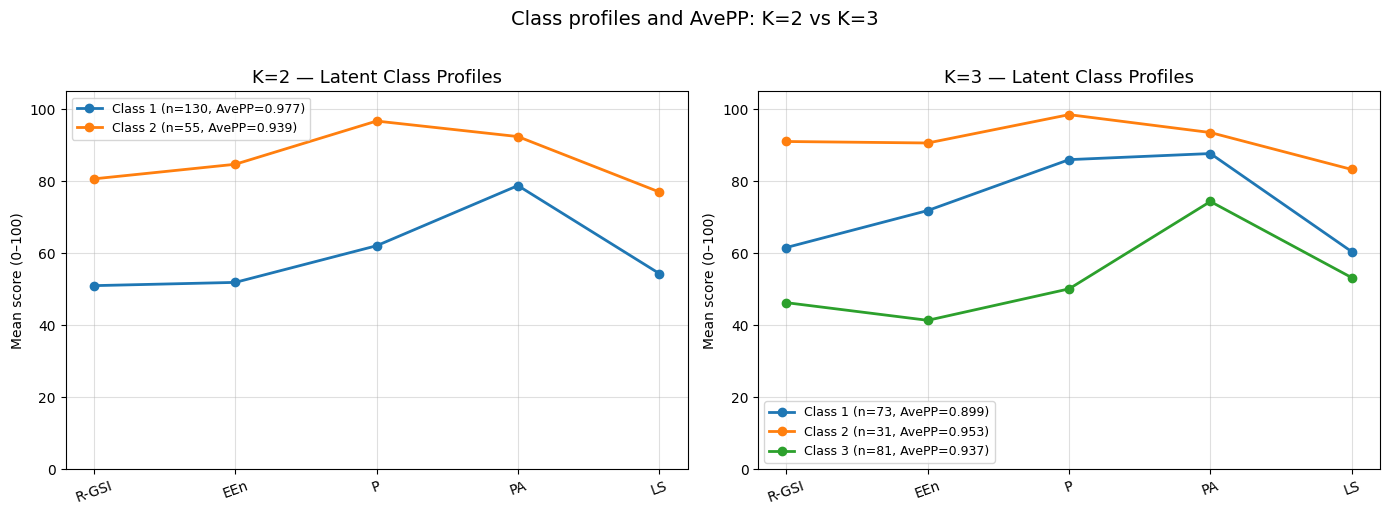


AvePP by class (higher = lower classification uncertainty)
-------------------------------------------------------

  K=2  |  Entropy=0.884
    Class 1: n=130 (70.3%)  AvePP=0.977
    Class 2: n= 55 (29.7%)  AvePP=0.939

  K=3  |  Entropy=0.832
    Class 1: n= 73 (39.5%)  AvePP=0.899
    Class 2: n= 31 (16.8%)  AvePP=0.953
    Class 3: n= 81 (43.8%)  AvePP=0.937


In [12]:

# ============================================================
# DETAILED AvePP BY CLASS AND MEAN PROFILE FOR K=2 AND K=3
# Allows evaluation if k=3 adds an interpretable class
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for ax, k in zip(axes, [2, 3]):
    m = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=42)
    m.fit(X_lca_input)
    labels = m.predict(X_lca_input)
    probs  = m.predict_proba(X_lca_input)
    avepp  = avepp_per_class(probs)
    sizes  = [(labels == c).sum() for c in range(k)]

    means = pd.DataFrame(X_lca_input.copy())
    means['Class'] = labels
    profile = means.groupby('Class').mean()

    for c in range(k):
        ax.plot(profile.columns, profile.iloc[c], marker='o', color=colors[c],
                label=f'Class {c+1} (n={sizes[c]}, AvePP={avepp[c]:.3f})', linewidth=2)

    ax.set_title(f'K={k} — Latent Class Profiles', fontsize=13)
    ax.set_ylabel('Mean score (0–100)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Class profiles and AvePP: K=2 vs K=3', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Detailed AvePP table for K=2 and K=3
print("\nAvePP by class (higher = lower classification uncertainty)")
print("-" * 55)
for k in [2, 3]:
    m = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=42, progress_bar=False)
    m.fit(X_lca_input)
    labels = m.predict(X_lca_input)
    probs  = m.predict_proba(X_lca_input)
    avepp  = avepp_per_class(probs)
    sizes  = [(labels == c).sum() for c in range(k)]
    ent    = relative_entropy(probs)
    print(f"\n  K={k}  |  Entropy={ent:.3f}")
    for c in range(k):
        print(f"    Class {c+1}: n={sizes[c]:3d} ({sizes[c]/len(labels)*100:4.1f}%)  AvePP={avepp[c]:.3f}")


In [13]:
paper_table = df_fit[['K','Log-L','AIC','BIC','Entropy','AvePP_min','Silhouette','Sizes_(n)']].copy()
paper_table = paper_table.merge(df_stab[['K','ARI_mean','ARI_std']], on='K')
paper_table['ARI'] = paper_table.apply(lambda r: f"{r.ARI_mean:.3f} ± {r.ARI_std:.3f}", axis=1)
paper_table = paper_table.drop(columns=['ARI_mean','ARI_std'])
print(paper_table.to_string(index=False))


 K   Log-L    AIC    BIC  Entropy  AvePP_min  Silhouette                Sizes_(n)           ARI
 2 -4026.9 8095.8 8163.4    0.884      0.939       0.248                [130, 55] 1.000 ± 0.000
 3 -3977.1 8018.3 8121.3    0.832      0.899       0.200             [73, 31, 81] 0.910 ± 0.111
 4 -3953.9 7993.9 8132.4    0.876      0.916       0.223         [31, 66, 77, 11] 0.656 ± 0.264
 5 -3919.7 7947.4 8121.3    0.869      0.896       0.151     [60, 11, 23, 63, 28] 0.276 ± 0.061
 6 -3676.5 7483.0 7692.3    0.858      0.761       0.074 [33, 33, 45, 25, 24, 25] 0.741 ± 0.200


In [ ]:
# ============================================================
# COMPLETE CLASS-SPECIFIC SOLUTION (K=2 vs K=3)
# Relative entropy, mean profiles, AvePP and cross-tabulation
# (contingency table and ARI) between K=2 and K=3
# ============================================================

from sklearn.metrics import adjusted_rand_score

variables = ['R-GSI', 'EEn', 'R-CY', 'PA', 'LS']

for k in [2, 3]:
    print(f"\n{'='*70}")
    print(f"  K = {k} — COMPLETE SOLUTION")
    print(f"{'='*70}")

    m = StepMix(n_components=k, measurement=measurement_dict, n_steps=1, random_state=42)
    m.fit(X_lca_input)
    labels = m.predict(X_lca_input)
    probs  = m.predict_proba(X_lca_input)

    # --- Relative entropy ---
    ent = relative_entropy(probs)
    print(f"\n  Relative Entropy : {ent:.3f}  (≥0.80 = excellent; ≥0.60 = acceptable)")

    # --- Mean profile table ---
    df_tmp = X_lca_input.copy()
    df_tmp['Class'] = labels
    profile = df_tmp.groupby('Class')[variables].mean().round(2)
    sizes   = df_tmp.groupby('Class').size()
    avepp   = avepp_per_class(probs)

    print(f"\n  {'Class':<8} {'n':>5} {'%':>6}  {'AvePP':>7}  " +
          "  ".join(f"{v:>8}" for v in variables))
    print("  " + "-"*75)
    for c in range(k):
        n_c = sizes[c]
        pct = n_c / len(labels) * 100
        row = profile.loc[c]
        print(f"  {c+1:<8} {n_c:>5} {pct:>5.1f}%  {avepp[c]:>7.3f}  " +
              "  ".join(f"{row[v]:>8.2f}" for v in variables))

    # --- Cross ARI between K=2 (reference) and K=3 ---
    if k == 3:
        m2 = StepMix(n_components=2, measurement=measurement_dict, n_steps=1, random_state=42)
        m2.fit(X_lca_input)
        labels2 = m2.predict(X_lca_input)

        print(f"\n  Cross-tabulation K=2 labels vs K=3 labels:")
        ct = pd.crosstab(labels2, labels, rownames=['K=2'], colnames=['K=3'])
        print(ct.to_string())
        ari_2v3 = adjusted_rand_score(labels2, labels)
        print(f"\n  ARI(K=2, K=3) = {ari_2v3:.3f}")
        print("  Interpretation: ARI close to 1 → K=3 classes map onto K=2 classes")
        print("                  ARI close to 0 → K=3 introduces a genuinely new partition")


  K = 2 — COMPLETE SOLUTION
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 22.17it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]



  Relative Entropy : 0.884  (≥0.80 = excellent; ≥0.60 = acceptable)

  Class        n      %    AvePP     R-GSI       EEn         P        PA        LS
  ---------------------------------------------------------------------------
  1          130  70.3%    0.977     50.99     51.90     62.08     78.80     54.37
  2           55  29.7%    0.939     80.68     84.73     96.74     92.42     77.04

  K = 3 — COMPLETE SOLUTION
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 20.03it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]



  Relative Entropy : 0.832  (≥0.80 = excellent; ≥0.60 = acceptable)

  Class        n      %    AvePP     R-GSI       EEn         P        PA        LS
  ---------------------------------------------------------------------------
  1           73  39.5%    0.899     61.60     71.87     86.02     87.71     60.44
  2           31  16.8%    0.953     91.06     90.65     98.52     93.55     83.29
  3           81  43.8%    0.937     46.26     41.36     50.10     74.38     53.22
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 20.57it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]


  Cross-tabulation K=2 labels vs K=3 labels:
K=3   0   1   2
K=2            
0    49   0  81
1    24  31   0

  ARI(K=2, K=3) = 0.335
  Interpretation: ARI close to 1 → K=3 classes map onto K=2 classes
                  ARI close to 0 → K=3 introduces a genuinely new partition


In [ ]:
# ============================================================
# DISTINCTIVENESS TEST FOR THE THIRD PROFILE (K=3)
# Centroid distances, intermediate class profile
# vs linear interpolation Low-High, and cross-seed stability
# ============================================================


from scipy.spatial.distance import cdist
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

m3 = StepMix(n_components=3, measurement=measurement_dict, n_steps=1, random_state=42)
m3.fit(X_lca_input)
labels3 = m3.predict(X_lca_input)
probs3  = m3.predict_proba(X_lca_input)

variables = ['R-GSI', 'EEn', 'R-CY', 'PA', 'LS']
df_k3 = X_lca_input.copy()
df_k3['Class'] = labels3
profile3 = df_k3.groupby('Class')[variables].mean()

print("=" * 70)
print("  THIRD PROFILE DISTINCTIVENESS TEST (K=3)")
print("=" * 70)

# 1. Euclidean distance between centroids (standardized)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lca_input)
centroids = np.array([X_scaled[labels3 == c].mean(axis=0) for c in range(3)])
dist_matrix = cdist(centroids, centroids, metric='euclidean')

print("\n1. Euclidean distance between standardized centroids (K=3):")
header = "        " + "  ".join(f"Class {c+1}" for c in range(3))
print(header)
for i in range(3):
    row = f"  Class {i+1}  " + "  ".join(f"{dist_matrix[i,j]:7.3f}" for j in range(3))
    print(row)
print("\n  NOTE: Distance < 1.0 between two classes suggests poor separation")
print("        (classes are within 1 SD of each other in standardized space)")

# 2. Mahalanobis-style overlap: what proportion of the "intermediate"
#    class falls within the ranges of classes 1 and 2
sizes3 = [(labels3 == c).sum() for c in range(3)]
# Sort classes by composite mean (to identify which one is intermediate)
composite = profile3.mean(axis=1).sort_values()
c_low, c_mid, c_high = composite.index.tolist()

print(f"\n2. Profile ordering by composite mean:")
print(f"   Low class   → Class {c_low+1}  (n={sizes3[c_low]})")
print(f"   Mid class   → Class {c_mid+1}  (n={sizes3[c_mid]})")
print(f"   High class  → Class {c_high+1} (n={sizes3[c_high]})")

# 3. For each variable: is the mid profile an average of low+high, or distinct?
print("\n3. Mid-class profile vs linear interpolation of Low and High:")
print(f"   {'Variable':<10} {'Low mean':>9} {'Mid mean':>9} {'High mean':>9} "
      f"{'Interpolated':>13} {'Residual':>9} {'Profile-distinct?':>18}")
print("   " + "-"*85)

any_distinct = False
for v in variables:
    lo  = profile3.loc[c_low,  v]
    mi  = profile3.loc[c_mid,  v]
    hi  = profile3.loc[c_high, v]
    # linear interpolation at the midpoint (weight 0.5)
    interp = (lo + hi) / 2
    resid  = abs(mi - interp)
    # "distinct" if it deviates >5 points from the linear interpolation (0-100 scale)
    distinct = "YES ✓" if resid > 5 else "no"
    if resid > 5:
        any_distinct = True
    print(f"   {v:<10} {lo:>9.2f} {mi:>9.2f} {hi:>9.2f} {interp:>13.2f} "
          f"{resid:>9.2f} {distinct:>18}")

print()
if any_distinct:
    print("  ✓ The mid-class shows a non-linear profile on at least one variable.")
    print("    This suggests it may capture a qualitatively distinct subgroup.")
else:
    print("  ✗ The mid-class profile is essentially a linear interpolation of the")
    print("    Low and High classes. It does not add a qualitatively distinct pattern.")
    print("    This is consistent with a unidimensional severity continuum, not")
    print("    with Keyes' categorical typology.")

# 4. Stability of the 3rd class specifically, across seeds
print("\n4. Stability of K=3 class membership across 20 random seeds:")
ref3 = labels3.copy()
aris_k3 = []
class_sizes_k3 = []
for seed in range(20):
    m_s = StepMix(n_components=3, measurement=measurement_dict, n_steps=1, random_state=seed)
    m_s.fit(X_lca_input)
    ls = m_s.predict(X_lca_input)
    aris_k3.append(adjusted_rand_score(ref3, ls))
    class_sizes_k3.append(sorted([(ls==c).sum() for c in range(3)]))

print(f"   ARI mean = {np.mean(aris_k3):.3f}  SD = {np.std(aris_k3):.3f}  "
      f"min = {np.min(aris_k3):.3f}")
print(f"   Smallest class size across seeds: "
      f"min={min(s[0] for s in class_sizes_k3)}, "
      f"max={max(s[0] for s in class_sizes_k3)}, "
      f"mean={np.mean([s[0] for s in class_sizes_k3]):.1f}")
print()
if np.mean(aris_k3) < 0.80:
    print("  → ARI < 0.80: K=3 labels are inconsistent across random starts.")
    print("    The partition is empirically unstable.")
elif np.std(aris_k3) > 0.10:
    print("  → High SD: although mean ARI is acceptable, variance is large.")
    print("    Some seeds produce substantially different partitions.")
else:
    print("  → K=3 is stable across seeds (ARI ≥ 0.80, low SD).")
    print("    Instability alone does not justify rejection; see profile analysis above.")

Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 19.15it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


  THIRD PROFILE DISTINCTIVENESS TEST (K=3)

1. Euclidean distance between standardized centroids (K=3):
        Class 1  Class 2  Class 3
  Class 1    0.000    1.933    2.113
  Class 2    1.933    0.000    3.779
  Class 3    2.113    3.779    0.000

  NOTE: Distance < 1.0 between two classes suggests poor separation
        (classes are within 1 SD of each other in standardized space)

2. Profile ordering by composite mean:
   Low class   → Class 3  (n=81)
   Mid class   → Class 1  (n=73)
   High class  → Class 2 (n=31)

3. Mid-class profile vs linear interpolation of Low and High:
   Variable    Low mean  Mid mean High mean  Interpolated  Residual  Profile-distinct?
   -------------------------------------------------------------------------------------
   R-GSI          46.26     61.60     91.06         68.66      7.06              YES ✓
   EEn            41.36     71.87     90.65         66.00      5.87              YES ✓
   P              50.10     86.02     98.52         74.31    

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 30.23it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 16.56it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 26.91it/s, max_LL=-3.98e+3, max_avg_LL=-21.5]

   ARI mean = 0.910  SD = 0.111  min = 0.774
   Smallest class size across seeds: min=31, max=32, mean=31.4

  → High SD: although mean ARI is acceptable, variance is large.
    Some seeds produce substantially different partitions.


In [16]:
## Latent Class Analysis (LCA) using StepMix

from stepmix.stepmix import StepMix

# Fit LCA model (StepMix)
n_classes = 2
model = StepMix(n_components=n_classes, measurement=measurement_dict, n_steps=1, random_state=42)
model.fit(X_lca_input)

# Get latent class membership
clusters_lca = model.predict(X_lca_input)

# Add the clusters to the DataFrame
TASS_df_clean = TASS_df.loc[X_lca_input.index].copy()
TASS_df_clean['Cluster_LCA'] = clusters_lca
print(TASS_df_clean['Cluster_LCA'].value_counts().sort_values(ascending=False))

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 24.81it/s, max_LL=-4.03e+3, max_avg_LL=-21.8]

Cluster_LCA
0    130
1     55
Name: count, dtype: int64


In [17]:
# Mapping Cluster_0 = worst well-being and Cluster_1 = best well-being
# LCA assigns cluster numbers arbitrarily during the EM algorithm convergence. 
# In this case, the original Cluster 0 had higher scores on all variables (better wellbeing), 
# which is counterintuitive. The .map({0: 1, 1: 0}) swaps the labels so Cluster 0 = low wellbeing and Cluster 1 = high wellbeing, 
# consistent with the study's interpretation.

TASS_df_clean['Cluster_LCA'] = TASS_df_clean['Cluster_LCA'].map({0: 0, 1: 1})

for cluster in TASS_df_clean['Cluster_LCA'].value_counts().index:
    ids_cluster = TASS_df_clean.loc[TASS_df_clean['Cluster_LCA'] == cluster, 'ID']
    print(f"IDs in Cluster {cluster}:")
    print(ids_cluster.tolist())
    print(f"Total: {len(ids_cluster)}\n")

IDs in Cluster 0:
[9, 13, 34, 35, 36, 39, 60, 61, 62, 63, 64, 68, 69, 71, 73, 74, 78, 81, 83, 86, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 100, 102, 103, 108, 109, 114, 118, 119, 238, 240, 241, 244, 246, 252, 255, 256, 258, 307, 311, 360, 366, 367, 368, 369, 373, 376, 382, 413, 415, 416, 417, 418, 423, 427, 428, 430, 439, 441, 446, 447, 449, 453, 470, 471, 504, 506, 507, 508, 509, 515, 516, 532, 539, 540, 548, 549, 568, 575, 596, 606, 615, 620, 622, 644, 645, 647, 650, 652, 653, 654, 655, 656, 657, 658, 660, 664, 665, 668, 672, 673, 676, 677, 678, 683, 687, 688, 690, 692, 693, 695, 696, 698, 700, 704, 714, 724, 725, 738, 742, 839]
Total: 130

IDs in Cluster 1:
[8, 65, 66, 67, 75, 76, 82, 99, 104, 105, 107, 117, 239, 247, 254, 306, 308, 316, 357, 359, 361, 364, 372, 377, 425, 431, 432, 434, 463, 465, 468, 505, 529, 536, 541, 543, 577, 584, 614, 623, 648, 659, 682, 689, 697, 699, 701, 702, 703, 705, 706, 707, 717, 722, 739]
Total: 55



In [18]:
# 2. Percentage Proportion
proporcion = TASS_df_clean['Cluster_LCA'].value_counts(normalize=True).sort_index()

print("\n📈 PERCENTAGE PROPORTION (%):")
print("-" * 60)
for cluster in sorted(TASS_df_clean['Cluster_LCA'].unique()):
    porcentaje = proporcion[cluster] * 100
    print(f"  Cluster {cluster}: {porcentaje:5.1f}%")



📈 PERCENTAGE PROPORTION (%):
------------------------------------------------------------
  Cluster 0:  70.3%
  Cluster 1:  29.7%


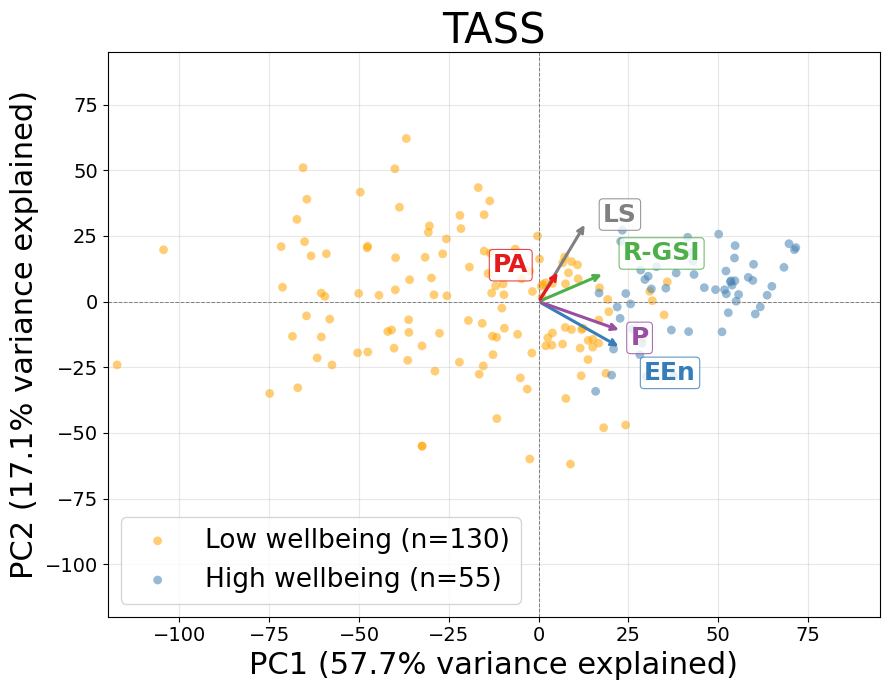

In [ ]:
## graph with variable loadings (arrows) in PCA space

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lca_input)

# Variance explained by each component
var_exp = pca.explained_variance_ratio_
loadings = pca.components_.T  # shape: (n_variables, 2)
feature_names = X_lca_input.columns.tolist()

df_pca_lca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_lca_input.index)
df_pca_lca['Cluster_LCA'] = TASS_df_clean['Cluster_LCA'].values

# Descriptive labels for the legend
cluster_labels = {0: f'Low wellbeing (n=130)', 1: f'High wellbeing (n=55)'}
palette_custom = {0: 'orange', 1: 'steelblue'}

fig, ax = plt.subplots(figsize=(9, 7))

for cluster, label in cluster_labels.items():
    idx = df_pca_lca['Cluster_LCA'] == cluster
    ax.scatter(df_pca_lca.loc[idx, 'PC1'], df_pca_lca.loc[idx, 'PC2'],
               label=label, color=palette_custom[cluster], alpha=0.55, s=40, edgecolors='none')

# Unique colors for each variable
colors_vars = {
    'LS':    '#808080',   # gray
    'PA':    '#e41a1c',   # red
    'R-GSI': '#4daf4a',   # green
    'R-CY':     '#984ea3',   # purple
    'EEn':    '#377eb8',   # dark blue
}

# Drawing order: higher zorder = on top
zorder_vars = {
    'EEn':    2,
    'R-CY':     2,
    'R-GSI': 2,
    'LS':    3,   # gray
    'PA':    4,   # red, on top of LS
}

scale = 40
for i, var in enumerate(feature_names):
    lx, ly = loadings[i, 0] * scale, loadings[i, 1] * scale
    color = colors_vars.get(var, 'black')
    z = zorder_vars.get(var, 2)

    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2),
                zorder=z)

    manual_offset = {
        'LS': (1, -10),
        'PA': (-20,  -6),
        'R-CY': (-4,  5),
    }

    offset = 0.28
    tx = lx * (1 + offset) + manual_offset.get(var, (0, 0))[0]
    ty = ly * (1 + offset) + manual_offset.get(var, (0, 0))[1]

    ha = 'left' if lx >= 0 else 'right'
    va = 'bottom' if ly >= 0 else 'top'

    ax.text(tx, ty, var, fontsize=18, ha=ha, va=va,
            fontweight='bold', color=color, zorder=z,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      alpha=0.8, edgecolor=color, linewidth=0.8))


# Ejes con varianza explicada
ax.tick_params(axis='both', labelsize=14)
ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75])
ax.set_yticks([-100, -75, -50, -25, 0, 25, 50, 75])
ax.set_xlim(-120, 95)
ax.set_ylim(-120, 95)

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variance explained)', fontsize=22)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variance explained)', fontsize=22)
ax.set_title('TASS', fontsize=30)

ax.axhline(0, color='grey', lw=0.7, linestyle='--')
ax.axvline(0, color='grey', lw=0.7, linestyle='--')

ax.legend(fontsize=19, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
## Statistical comparison of clusters: Mann-Whitney U test and Cohen's d with bootstrap confidence intervals

from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def cohens_d(x1, x2):
    return (np.mean(x1) - np.mean(x2)) / np.sqrt((np.std(x1, ddof=1) ** 2 + np.std(x2, ddof=1) ** 2) / 2)

def bootstrap_cohens_d(x1, x2, n_boot=1000, random_state=42):
    np.random.seed(random_state)
    boot_ds = []
    x1 = np.array(x1)
    x2 = np.array(x2)
    for _ in range(n_boot):
        boot_x1 = np.random.choice(x1, size=len(x1), replace=True)
        boot_x2 = np.random.choice(x2, size=len(x2), replace=True)
        boot_ds.append(cohens_d(boot_x1, boot_x2))
    return np.percentile(boot_ds, [2.5, 97.5])

tabla_medias = pd.DataFrame(columns=['Variable', 'Cluster_0', 'Cluster_1', 'MW_p', 'Cohens_d', 'Cohens_d_IC'])

for var in numericas:
    grupo0 = TASS_df_clean[TASS_df_clean['Cluster_LCA'] == 0][var]
    grupo1 = TASS_df_clean[TASS_df_clean['Cluster_LCA'] == 1][var]
    media0 = f'{grupo0.mean():.2f}'
    media1 = f'{grupo1.mean():.2f}'
    u_stat, p_val = mannwhitneyu(grupo0, grupo1, alternative='two-sided')
    d = abs(cohens_d(grupo0, grupo1))
    ic_low, ic_high = bootstrap_cohens_d(grupo0, grupo1)
    ic_low, ic_high = abs(ic_low), abs(ic_high)
    tabla_medias = pd.concat([
        tabla_medias,
        pd.DataFrame({
            'Variable': [var],
            'Cluster_0': media0,
            'Cluster_1': media1,
            'MW_p': [round(p_val, 3)],
            'Cohens_d': [round(d, 3)],
            'Cohens_d_IC': [f"[{ic_low:.2f}, {ic_high:.2f}]"]
        })
    ], ignore_index=True)

tabla_medias['MW_p'] = tabla_medias['MW_p'].astype(float).map('{:.3f}'.format)

tabla_medias

,Variable,Cluster_0,Cluster_1,MW_p,Cohens_d,Cohens_d_IC
0,R-GSI,50.99,80.68,0.000,1.751,"[2.16, 1.40]"
1,EEn,51.90,84.73,0.000,1.691,"[2.03, 1.38]"
2,P,62.08,96.74,0.000,1.931,"[2.19, 1.71]"
3,PA,78.80,92.42,0.000,1.001,"[1.27, 0.77]"
4,LS,54.37,77.04,0.000,1.223,"[1.55, 0.91]"


In [21]:
## Calculate variable importance using Random Forest values

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer, accuracy_score, recall_score, precision_score

numericas = [col for col in TASS_df_clean.columns if col not in ['ID', 'Cluster_LCA']]
variables_rf = numericas

X_rf = TASS_df_clean[variables_rf]
y_rf = TASS_df_clean['Cluster_LCA']

variables_rf = numericas

# Prepare the data
X_rf = TASS_df_clean[variables_rf]
y_rf = TASS_df_clean['Cluster_LCA']

# Define stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metrics
scoring = {
    'AUC': 'roc_auc',
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision'
}

# Train and evaluate with cross-validation
rf = RandomForestClassifier(n_estimators=50, random_state=42)
cv_results = cross_validate(rf, X_rf, y_rf, cv=cv, scoring=scoring, return_train_score=False)

# Show average results and standard deviation
print("=== Cross-validation metrics (5-fold) ===")
for metric in scoring:
    print(f"{metric}: {cv_results['test_' + metric].mean():.3f} ± {cv_results['test_' + metric].std():.3f}")

# Train the final model on the entire dataset to get feature importances
rf.fit(X_rf, y_rf)

# Variable importance
importances = rf.feature_importances_
features = X_rf.columns

# Show the most important variables sorted
importancia_df = pd.DataFrame({'Variable': features, 'Importancia': importances})
importancia_df = importancia_df.sort_values('Importancia', ascending=False)
print(importancia_df)

numericas = [col for col in TASS_df_clean.columns if col not in ['ID', 'Cluster_LCA']]
variables_rf = numericas
X_rf = TASS_df_clean[variables_rf]
y_rf = TASS_df_clean['Cluster_LCA']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'AUC': 'roc_auc', 'accuracy': 'accuracy', 'recall': 'recall', 'precision': 'precision'}

rf = RandomForestClassifier(n_estimators=50, random_state=42)
cv_results = cross_validate(rf, X_rf, y_rf, cv=cv, scoring=scoring, return_train_score=False)

print("=== Métricas de validación cruzada (5-fold) ===")
for metric in scoring:
    print(f"{metric}: {cv_results['test_' + metric].mean():.3f} ± {cv_results['test_' + metric].std():.3f}")

rf.fit(X_rf, y_rf)

importances = rf.feature_importances_
importancia_df = pd.DataFrame({'Variable': X_rf.columns, 'Importancia': importances})
importancia_df = importancia_df.sort_values('Importancia', ascending=False)
print(importancia_df)

# --- Importances by cluster ---
import shap
np.bool = bool

explainer = shap.Explainer(rf, X_rf)
shap_values = explainer(X_rf, check_additivity=False)

importancias_por_cluster = {}
for cluster in [0, 1]:
    mask = (TASS_df_clean['Cluster_LCA'] == cluster).values
    shap_cluster = np.abs(shap_values.values[mask, :, cluster])
    imp = pd.Series(shap_cluster.mean(axis=0), index=X_rf.columns)
    importancias_por_cluster[cluster] = imp
    print(f"\nImportances Cluster {cluster}:")
    print(imp.sort_values(ascending=False).round(4))


=== Cross-validation metrics (5-fold) ===
AUC: 0.986 ± 0.008
accuracy: 0.924 ± 0.043
recall: 0.855 ± 0.093
precision: 0.903 ± 0.104
  Variable  Importancia
2        P     0.430482
0    R-GSI     0.201141
1      EEn     0.176160
4       LS     0.125618
3       PA     0.066599
=== Métricas de validación cruzada (5-fold) ===
AUC: 0.986 ± 0.008
accuracy: 0.924 ± 0.043
recall: 0.855 ± 0.093
precision: 0.903 ± 0.104
  Variable  Importancia
2        P     0.430482
0    R-GSI     0.201141
1      EEn     0.176160
4       LS     0.125618
3       PA     0.066599

Importances Cluster 0:
P        0.1539
EEn      0.0644
R-GSI    0.0636
LS       0.0383
PA       0.0247
dtype: float64

Importances Cluster 1:
P        0.2972
EEn      0.1275
R-GSI    0.1269
LS       0.0685
PA       0.0426
dtype: float64


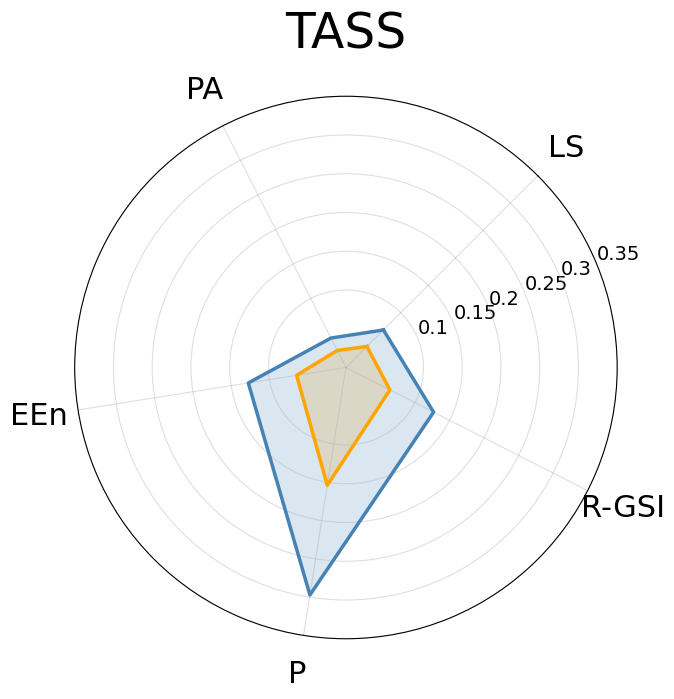

In [ ]:
## Radar plot of variable importance by cluster

orden_variables = ['LS', 'R-GSI', 'R-CY', 'EEn', 'PA']

angles = np.linspace(0, 2 * np.pi, len(orden_variables), endpoint=False).tolist()
angles += angles[:1]

colors_cluster = {0: 'orange', 1: 'steelblue'}

fig, ax = plt.subplots(figsize=(7, 8), subplot_kw=dict(polar=True))
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_theta_offset(np.radians(45))

for cluster in [0, 1]:
    valores = importancias_por_cluster[cluster][orden_variables].tolist()
    valores += valores[:1]
    ax.plot(angles, valores, '-', linewidth=2.5,
            color=colors_cluster[cluster])
    ax.fill(angles, valores, alpha=0.2, color=colors_cluster[cluster])

ax.set_thetagrids(np.degrees(angles[:-1]), orden_variables, fontsize=22)
ax.set_ylim(0, 0.35)
ax.set_yticks([0.1, 0.15, 0.2, 0.25, 0.3, 0.35])
ax.set_yticklabels(['0.1', '0.15', '0.2', '0.25', '0.3', '0.35'], fontsize=14, color='black')
ax.tick_params(pad=18)
ax.set_title('TASS', pad=35, fontsize=35)
ax.grid(True, alpha=0.4)

# fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.02),
#            ncol=2, fontsize=11, frameon=True)
plt.subplots_adjust(bottom=0.12)
plt.show()
